In [1]:
%run setup_matplotlib.ipynb

In [5]:
import numpy as np

_b = np.arange(1 << 16, dtype=np.uint16).view(np.uint8).reshape(-1, 2)
HW16 = np.unpackbits(_b, axis=1).sum(axis=1).astype(np.uint8)

def hw_u16(x):
    return HW16[(x.astype(np.int64) & 0xFFFF).astype(np.uint16)].astype(np.float32)

def hw_i32(x):
    x = x.astype(np.int64) & 0xFFFFFFFF
    return HW16[(x & 0xFFFF).astype(np.uint16)].astype(np.float32) + \
           HW16[((x>>16)&0xFFFF).astype(np.uint16)].astype(np.float32)


In [18]:
np.random.seed(0)

N = 10000
sigma = 4

X = np.random.randint(0, 1<<32, N)

X_hw = hw_i32(X)
L = X_hw + np.random.normal(0, sigma, N)

np.corrcoef(X_hw, L)

array([[1.        , 0.57955269],
       [0.57955269, 1.        ]])

In [40]:
N = 200000
sigma = 4
#n_sigma = 10

X = np.random.randint(0, 1<<32, N)
#sigmas = np.linspace(0, 1, n_sigma+1)
sigmas = np.arange(0, 10, 0.01)

n_sigma = 1000

corrs = [0] * (n_sigma)
for i, sigma in enumerate(sigmas):
    X_hw = hw_i32(X)
    L = X_hw + np.random.normal(0, sigma, N)
    
    corrs[i] = np.corrcoef(X_hw, L)[0][1]

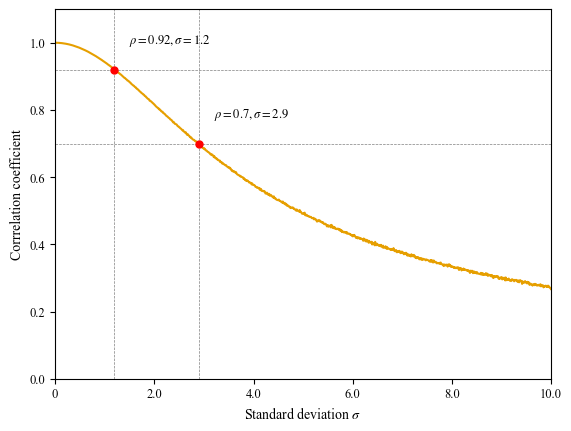

In [72]:
import matplotlib.pyplot as plt
#print(corrs)

plt.xlim(0, 999)
plt.ylim(0, 1.1)

plt.xlabel(r"Standard deviation $\sigma$")
plt.ylabel("Corrrelation coefficient")

plt.xticks([0, 200, 400, 600, 800, 999], ["0", "2.0", "4.0", "6.0", "8.0", "10.0"])
plt.plot(corrs)

# rho = 0.7, sigma = 2.9 の補助線
rho_target = 0.7
sigma_target = 2.9
x_target = sigma_target / 0.01  # sigmas の刻み幅(0.01)に合わせてインデックスに変換

plt.axhline(y=rho_target, color="gray", linestyle="--", linewidth=0.5)
plt.axvline(x=x_target, color="gray", linestyle="--", linewidth=0.5)
plt.plot(x_target, rho_target, "ro", markersize=5)  # 交点マーカー
plt.annotate(
    rf"$\rho={rho_target}, \sigma={sigma_target}$",
    xy=(x_target, rho_target),
    xytext=(x_target + 30, rho_target + 0.08),
    fontsize=9,
)

# rho = 0.92, sigma = 1.2 の補助線
rho_target = 0.92
sigma_target = 1.2
x_target = sigma_target / 0.01  # sigmas の刻み幅(0.01)に合わせてインデックスに変換

plt.axhline(y=rho_target, color="gray", linestyle="--", linewidth=0.5)
plt.axvline(x=x_target, color="gray", linestyle="--", linewidth=0.5)
plt.plot(x_target, rho_target, "ro", markersize=5)  # 交点マーカー
plt.annotate(
    rf"$\rho={rho_target}, \sigma={sigma_target}$",
    xy=(x_target, rho_target),
    xytext=(x_target + 30, rho_target + 0.08),
    fontsize=9,
)

plt.savefig("images/noise_corrs.pdf", bbox_inches="tight")
plt.show()

In [73]:
!pdfcrop images/noise_corrs.pdf

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `images/noise_corrs-crop.pdf'.


In [61]:
corrs[120], corrs[290]

(0.920339797231196, 0.6984934614334951)

In [66]:
import numpy as np

sgm_95 = 1.2
sgm_70 = 2.9

sigma_k32 = 2*np.sqrt(2)

def SNR1(sgm):
    nume = sigma_k32**2 + sgm**2
    deno = sgm**2
    return nume / deno

def SNR2(sgm):
    new_noise = (sigma_k32**2 + sgm**2)
    nume = sigma_k32**2 + new_noise
    deno = new_noise
    return nume / deno

def SNR_factor(sgm):
    return SNR1(sgm) / SNR2(sgm)


print(sgm_95, SNR_factor(sgm_95))
print(sgm_70, SNR_factor(sgm_70))


1.2 3.5484199796126403
2.9 1.3117569893237848
